<a href="https://colab.research.google.com/github/vaishnavipokhriyal083-sudo/DeepLearningHandson/blob/main/deeplearning_handson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CNN**

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train) , (X_test, y_test) = cifar10.load_data()  ## load dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 203s 1us/step


In [ ]:
print(X_train.shape , y_train.shape)

(50000, 32, 32, 3) (50000, 1)


In [ ]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [ ]:
X_train, y_train

(array([[[[0.23137255, 0.24313726, 0.24705882],
          [0.16862746, 0.18039216, 0.1764706 ],
          [0.19607843, 0.1882353 , 0.16862746],
          ...,
          [0.61960787, 0.5176471 , 0.42352942],
          [0.59607846, 0.49019608, 0.4       ],
          [0.5803922 , 0.4862745 , 0.40392157]],
 
         [[0.0627451 , 0.07843138, 0.07843138],
          [0.        , 0.        , 0.        ],
          [0.07058824, 0.03137255, 0.        ],
          ...,
          [0.48235294, 0.34509805, 0.21568628],
          [0.46666667, 0.3254902 , 0.19607843],
          [0.47843137, 0.34117648, 0.22352941]],
 
         [[0.09803922, 0.09411765, 0.08235294],
          [0.0627451 , 0.02745098, 0.        ],
          [0.19215687, 0.10588235, 0.03137255],
          ...,
          [0.4627451 , 0.32941177, 0.19607843],
          [0.47058824, 0.32941177, 0.19607843],
          [0.42745098, 0.28627452, 0.16470589]],
 
         ...,
 
         [[0.8156863 , 0.6666667 , 0.3764706 ],
          [0.78823

In [ ]:
X_test, y_test

(array([[[[0.61960787, 0.4392157 , 0.19215687],
          [0.62352943, 0.43529412, 0.18431373],
          [0.64705884, 0.45490196, 0.2       ],
          ...,
          [0.5372549 , 0.37254903, 0.14117648],
          [0.49411765, 0.35686275, 0.14117648],
          [0.45490196, 0.33333334, 0.12941177]],
 
         [[0.59607846, 0.4392157 , 0.2       ],
          [0.5921569 , 0.43137255, 0.15686275],
          [0.62352943, 0.44705883, 0.1764706 ],
          ...,
          [0.53333336, 0.37254903, 0.12156863],
          [0.49019608, 0.35686275, 0.1254902 ],
          [0.46666667, 0.34509805, 0.13333334]],
 
         [[0.5921569 , 0.43137255, 0.18431373],
          [0.5921569 , 0.42745098, 0.12941177],
          [0.61960787, 0.43529412, 0.14117648],
          ...,
          [0.54509807, 0.38431373, 0.13333334],
          [0.50980395, 0.37254903, 0.13333334],
          [0.47058824, 0.34901962, 0.12941177]],
 
         ...,
 
         [[0.26666668, 0.4862745 , 0.69411767],
          [0.16470

In [ ]:
y_train_cat = to_categorical(y_train , 10)
y_test_cat = to_categorical(y_test , 10)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32 , (3,3), padding = 'same',activation = 'relu', input_shape = (32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), padding= 'same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
     X_train , y_train_cat ,
     validation_split = 0.2 ,
     epochs = 5,
     batch_size = 32
 )

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 60ms/step - accuracy: 0.4143 - loss: 1.5988 - val_accuracy: 0.5555 - val_loss: 1.2602
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 59ms/step - accuracy: 0.5425 - loss: 1.2717 - val_accuracy: 0.6144 - val_loss: 1.0907
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - accuracy: 0.5965 - loss: 1.1336 - val_accuracy: 0.6418 - val_loss: 1.0186
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.6316 - loss: 1.0432 - val_accuracy: 0.6625 - val_loss: 0.9602
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 74s 59ms/step - accuracy: 0.6560 - loss: 0.9728 - val_accuracy: 0.6789 - val_loss: 0.9314


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6722 - loss: 0.9368
Test accuracy: 0.6722000241279602


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers , models

In [ ]:
!find/content -type d -name "Training_set"

/bin/bash: line 1: find/content: No such file or directory


In [ ]:
!find /content -type d -name "Training_set"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find /content/drive -type d -name "Training_set"

In [ ]:
train_datagen =ImageDataGenerator(
    rescale=1/255,
    rotation_range = 15,
    zoom_range = 0.3,
    horizontal_flip = True,
    validation_split = 0.2
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    '/content/drive/My Drive',
    target_size = (64,64),
    batch_size = 32,
    class_mode = 'binary',
    subset = 'training'
)

val_data = train_datagen.flow_from_directory(
    '/content/drive/My Drive',
    target_size = (64,64),
    batch_size = 32,
    class_mode = 'binary',
    subset = 'validation'
)

Found 62 images belonging to 8 classes.
Found 15 images belonging to 8 classes.


**RNN**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TextVectorization, Embedding, SimpleRNN, Dense)

In [ ]:
texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "The film was excellent",
    "I really enjoyed the movie",
    "This was a wonderful film",
    "The acting was very good",
    "I like this movie",
    "What a fantastic movie",

    "I hate this movie",
    "This movie is terrible",
    "The film was awful",
    "I do not enjoy the movie",
    "This was a boring film",
    "The acting was very  bad"
])


In [ ]:
labels  = np.array([
    1,1,1,1,1,1,1,1,
    0,0,0,0,0,0
])

In [ ]:
texts = tf.constant(texts , dtype = tf.string)
labels = tf.constant(labels , dtype = tf.float32)

In [ ]:
vectorizer = TextVectorization(
    max_tokens = 1000,
    output_mode = "int",
    output_sequence_length = 6
)
vectorizer.adapt(texts)

In [ ]:
print(vectorizer.get_vocabulary())


['', '[UNK]', np.str_('movie'), np.str_('this'), np.str_('was'), np.str_('the'), np.str_('i'), np.str_('film'), np.str_('a'), np.str_('very'), np.str_('is'), np.str_('acting'), np.str_('wonderful'), np.str_('what'), np.str_('terrible'), np.str_('really'), np.str_('not'), np.str_('love'), np.str_('like'), np.str_('hate'), np.str_('good'), np.str_('fantastic'), np.str_('excellent'), np.str_('enjoyed'), np.str_('enjoy'), np.str_('do'), np.str_('boring'), np.str_('bad'), np.str_('awful'), np.str_('amazing')]


In [ ]:
sample = np.array(["I love this movie"])
print("original sentences:")
print(sample)
print("\n After vectorization:")
print(vectorizer(sample))

sample2 = np.array(["I love this film "])
print("\n After vectorization:")
print(vectorizer(sample2))

original sentences:
['I love this movie']

 After vectorization:
tf.Tensor([[ 6 17  3  2  0  0]], shape=(1, 6), dtype=int64)

 After vectorization:
tf.Tensor([[ 6 17  3  7  0  0]], shape=(1, 6), dtype=int64)


In [ ]:
vocab_size = len(vectorizer.get_vocabulary())

In [ ]:
model = Sequential([Input(shape = (1,), dtype = tf.string),
                    vectorizer,
                    Embedding(input_dim = vocab_size, output_dim = 8, mask_zero = True),
                    SimpleRNN(units = 16, activation = 'tanh'),
                    Dense(1, activation ='sigmoid')
])

In [ ]:
model.compile(optimizer ='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
texts

<tf.Tensor: shape=(14,), dtype=string, numpy=
array([b'I love this movie', b'This movie is amazing',
       b'The film was excellent', b'I really enjoyed the movie',
       b'This was a wonderful film', b'The acting was very good',
       b'I like this movie', b'What a fantastic movie',
       b'I hate this movie', b'This movie is terrible',
       b'The film was awful', b'I do not enjoy the movie',
       b'This was a boring film', b'The acting was very  bad'],
      dtype=object)>

In [ ]:
labels

<tf.Tensor: shape=(14,), dtype=float32, numpy=
array([1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
      dtype=float32)>

In [ ]:
model.fit(
    texts,
    labels,
    epochs = 100,
    batch_size = 4,
    verbose = 0
)

In [ ]:
test_sentences = np.array([
    "I really love the film",
    "This movie was very bad"
])

In [ ]:
test_sentences = tf.constant(test_sentences , dtype = tf.string)

In [ ]:
predictions = model.predict(test_sentences)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


array([[0.99884003],
       [0.16784583]], dtype=float32)

In [ ]:
predicted_classes = (predictions >= 0.5).astype(int)
print(predicted_classes)

[[1]
 [0]]


**LSTM**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, TextVectorization, Embedding, LSTM, Dense)

In [ ]:
texts = np.array([
    "I love this movie",
    "This movie is amazing",
    "The film was excellent",
    "I really enjoyed the movie",
    "This was a wonderful film",
    "The acting was very good",
    "I like this movie",
    "What a fantastic movie",

    "I hate this movie",
    "This movie is terrible",
    "The film was awful",
    "I do not enjoy the movie",
    "This was a boring film",
    "The acting was very  bad"
])

labels  = np.array([
    1,1,1,1,1,1,1,1,
    0,0,0,0,0,0
])

In [ ]:
texts = tf.constant(texts , dtype = tf.string)
labels = tf.constant(labels , dtype = tf.float32)

In [ ]:
vectorizer = TextVectorization(
    max_tokens = 1000,
    output_mode = "int",
    output_sequence_length = 6
)
vectorizer.adapt(texts)

In [ ]:
vocab_size = len(vectorizer.get_vocabulary())

In [ ]:
print(type(texts))
print(type(labels))
sample = np.array(["I love this movie"])
print("original sentences:")
print(sample)
print("\n After vectorization:")
print(vectorizer(sample))

sample2 = np.array(["I love this film "])
print("\n After vectorization:")
print(vectorizer(sample2))

<class 'tensorflow.python.framework.ops.EagerTensor'>
<class 'tensorflow.python.framework.ops.EagerTensor'>
original sentences:
['I love this movie']

 After vectorization:
tf.Tensor([[ 6 17  3  2  0  0]], shape=(1, 6), dtype=int64)

 After vectorization:
tf.Tensor([[ 6 17  3  7  0  0]], shape=(1, 6), dtype=int64)


In [ ]:
texts

<tf.Tensor: shape=(14,), dtype=string, numpy=
array([b'I love this movie', b'This movie is amazing',
       b'The film was excellent', b'I really enjoyed the movie',
       b'This was a wonderful film', b'The acting was very good',
       b'I like this movie', b'What a fantastic movie',
       b'I hate this movie', b'This movie is terrible',
       b'The film was awful', b'I do not enjoy the movie',
       b'This was a boring film', b'The acting was very  bad'],
      dtype=object)>

In [ ]:
labels

<tf.Tensor: shape=(14,), dtype=float32, numpy=
array([1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
      dtype=float32)>

In [ ]:
model = Sequential([Input(shape = (1,), dtype = tf.string),
                    vectorizer,
                    Embedding(input_dim = vocab_size, output_dim = 8, mask_zero = True),
                    LSTM(units = 16, activation = 'tanh', recurrent_activation ="sigmoid", return_sequences = False),
                    Dense(1, activation ='sigmoid')
])

In [ ]:
model

<Sequential name=sequential_2, built=True>

In [ ]:
model.compile(optimizer ='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
model.fit(
    texts,
    labels,
    epochs = 100,
    batch_size = 4,
    verbose = 0
)

In [ ]:
test_sentences = np.array([
    "I really love the film",
    "This movie was very bad"
])

In [ ]:
test_sentences = tf.constant(test_sentences , dtype = tf.string)

In [ ]:
predictions = model.predict(test_sentences)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.99988455],
       [0.09800176]], dtype=float32)

In [ ]:
predicted_classes = (predictions >= 0.5).astype(int)
print(predicted_classes)

[[1]
 [0]]


**Encoders and Decoders**




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# lload the dataset

(x_train,_),(x_test,_) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalization
#converting int pixels to float as nn works better with float values and the scaling it to bring pixel value batween 0 to 1

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

In [ ]:
print(x_train.shape)

(60000, 28, 28)


In [ ]:
x_train = x_train.reshape(len(x_train),784)
x_test = x_test.reshape(len(x_test),784)

In [ ]:
print(x_train.shape)

(60000, 784)


In [ ]:
LATENT_DIM = 32


In [ ]:
input_img = Input(shape = (784,), name = "image_vector" )

In [ ]:
encoded = Dense(
    LATENT_DIM ,
    activation = 'relu',
    name = 'Latent_code'
)(input_img)

In [ ]:
encoded

<KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_21>

In [ ]:
decoded = Dense(784, activation = "sigmoid",
                name="reconstruction")(encoded)

In [ ]:
autoencoder = Model(
    inputs= input_img,
    outputs = decoded,
    name = "dense_autoencoder"
)

In [ ]:
autoencoder

<Functional name=dense_autoencoder, built=True>

In [ ]:
encoder = Model(
    inputs = input_img,
    outputs = encoded,
    name = "encoder"
)

In [ ]:
autoencoder.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "binary_crossentropy",
    metrics = [tf.keras.metrics.MeanSquaredError(name="mse")]
)

In [ ]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)
early_stop

In [ ]:
history = autoencoder.fit(
    x = x_train,
    y = x_train,
    validation_data = (x_test, x_test),
    epochs = 20,
    batch_size=256,
    shuffle = True,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2779 - mse: 0.0699 - val_loss: 0.1919 - val_mse: 0.0414
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1704 - mse: 0.0344 - val_loss: 0.1531 - val_mse: 0.0288
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1439 - mse: 0.0258 - val_loss: 0.1337 - val_mse: 0.0226
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1281 - mse: 0.0207 - val_loss: 0.1208 - val_mse: 0.0185
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1178 - mse: 0.0174 - val_loss: 0.1125 - val_mse: 0.0159
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1107 - mse: 0.0152 - val_loss: 0.1065 - val_mse: 0.0140
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1055 - mse: 0.0136 - val_loss: 0.1021 - val_mse: 0.0126
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1018 - mse: 0.0125 - val_loss: 0.0990 - val_mse: 0.0118
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/

In [ ]:
reconstructed = autoencoder.predict(x_test)
latent_vectors = encoder.predict(x_test[:10], verbose = 0)
print("Input shape: ", x_test[:10].shape)
print("Latent shape: ",latent_vectors.shape)
print("Reconstruction shape: ", reconstructed.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Input shape:  (10, 784)
Latent shape:  (10, 32)
Reconstruction shape:  (10000, 784)


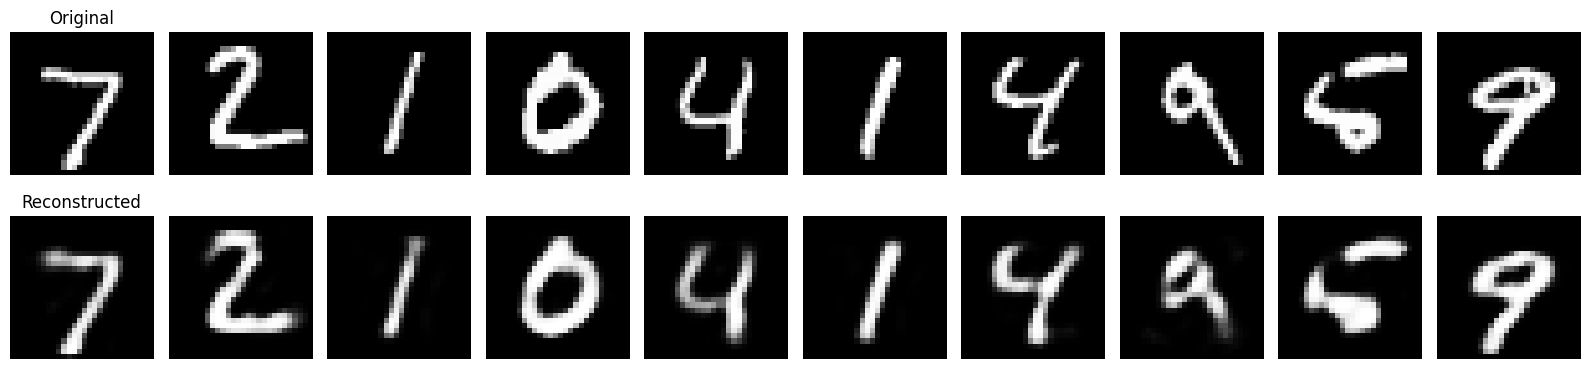

In [ ]:
n=10
plt.figure(figsize=(16,4))
for i in range (n):
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap="grey")
  plt.axis("off")
  if i==0:
    ax.set_title("Original")

  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(reconstructed[i].reshape(28,28), cmap="grey")
  plt.axis("off")
  if i==0:
    ax.set_title("Reconstructed")
plt.tight_layout()
plt.show()